# Day 3-1: CNN 기초 - Convolution과 구성요소

---

## 라이브러리 불러오기

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.9.0+cu126


---

## 1.1 Convolution 연산 이해하기

## 🎯 Convolution이란?

이미지에서 **특징**을 추출하는 핵심 연산입니다.

**filter**의 역할: filter의 값에 해당하는 특징이 이미지 어디에 어떻게 분포해 있는지를 찾아내는 역할

**3가지 핵심 개념:**
1. **Kernel Size**: 필터의 크기 (예: 3×3, 5×5)
2. **Stride**: 필터가 이동하는 보폭
3. **Padding**: 이미지 가장자리에 추가하는 0

**출력 크기 공식:**
```
Output_size = (Input_size - Kernel_size + 2×Padding) / Stride + 1
```

![이미지 설명](https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Fdo6lCs%2FbtssHxpKr0u%2FAAAAAAAAAAAAAAAAAAAAAFjJz21sN87p4iEUp8MPo-zEND8gCOS0jSktTzdGbcni%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1772290799%26allow_ip%3D%26allow_referer%3D%26signature%3DC69j7AX%252FXNzU8W068EyXuLN1Iq8%253D)


---

In [ ]:
# 간단한 Convolution 예제
# 3x3 입력 이미지
image = torch.tensor([[1., 2., 3.],
                      [4., 5., 6.],
                      [7., 8., 9.]])

# 2x2 필터 (수평 엣지 검출)
kernel = torch.tensor([[1., -1.],
                       [1., -1.]])

print("입력 이미지:")
print(image)
print("\n필터:")
print(kernel)

# PyTorch Conv2d를 위한 형태 변환 (batch, channel, height, width)
image_4d = image.unsqueeze(0).unsqueeze(0)  # [1, 1, 3, 3]
kernel_4d = kernel.unsqueeze(0).unsqueeze(0)  # [1, 1, 2, 2]

# Convolution 연산
output = F.conv2d(image_4d, kernel_4d)
print("\nConvolution 결과:")
print(output.squeeze())

입력 이미지:
tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])

필터:
tensor([[ 1., -1.],
        [ 1., -1.]])

Convolution 결과:
tensor([[-2., -2.],
        [-2., -2.]])


### ✏️ 실습 1-1: 다양한 필터 실험

다음 필터들을 사용해서 convolution 결과를 확인해보세요:
1. 수직 엣지 검출 필터: `[[1, -1], [1, -1]]`을 90도 회전
2. 블러(Blur) 필터: 모든 값이 0.25인 2x2 필터

In [ ]:
# 수직 엣지 검출 필터
vertical_kernel = torch.tensor([[1, 1],
                                [-1, -1]], dtype=torch.float32)

# Convolution 수행
vertical_kernel_4d = vertical_kernel.unsqueeze(0).unsqueeze(0)
output_vertical = F.conv2d(image_4d, vertical_kernel_4d)

print("수직 엣지 검출 결과:")
print(output_vertical.squeeze())

수직 엣지 검출 결과:
tensor([[-6., -6.],
        [-6., -6.]])


In [ ]:
# 블러 필터
blur_kernel = torch.tensor([[0.25, 0.25],
                            [0.25, 0.25]], dtype=torch.float32)

blur_kernel_4d = blur_kernel.unsqueeze(0).unsqueeze(0)
output_blur = F.conv2d(image_4d, blur_kernel_4d)

print("블러 필터 결과:")
print(output_blur.squeeze())

블러 필터 결과:
tensor([[3., 4.],
        [6., 7.]])


---

## 1.2 Padding과 Stride

### Padding
- 입력 이미지 주변에 0을 추가
- **목적**: 출력 크기 유지, 모서리 정보 보존
- `padding=1`: 상하좌우에 1픽셀씩 0 추가

### Stride
- 필터가 이동하는 간격
- `stride=1`: 1픽셀씩 이동 (기본값)
- `stride=2`: 2픽셀씩 이동 → 출력 크기 감소

### 출력 크기 계산 공식
```
출력 크기 = (입력 크기 - 커널 크기 + 2×Padding) / Stride + 1
```

In [ ]:
# 5x5 입력 이미지
image_5x5 = torch.randn(1, 1, 5, 5)

# 3x3 커널
kernel_3x3 = torch.randn(1, 1, 3, 3)

print("입력 크기:", image_5x5.shape)

# 1) Padding=0, Stride=1 (기본)
out1 = F.conv2d(image_5x5, kernel_3x3, padding=0, stride=1)
print(f"Padding=0, Stride=1 → 출력: {out1.shape}")

# 2) Padding=1, Stride=1
out2 = F.conv2d(image_5x5, kernel_3x3, padding=1, stride=1)
print(f"Padding=1, Stride=1 → 출력: {out2.shape}")

# 3) Padding=0, Stride=2
out3 = F.conv2d(image_5x5, kernel_3x3, padding=0, stride=2)
print(f"Padding=0, Stride=2 → 출력: {out3.shape}")

입력 크기: torch.Size([1, 1, 5, 5])
Padding=0, Stride=1 → 출력: torch.Size([1, 1, 3, 3])
Padding=1, Stride=1 → 출력: torch.Size([1, 1, 5, 5])
Padding=0, Stride=2 → 출력: torch.Size([1, 1, 2, 2])


### ✏️ 실습 1-2: 출력 크기 예측하기

공식을 사용해서 출력 크기를 계산하고, 실제 결과와 비교해보세요.

In [ ]:
# 28x28 입력, 5x5 커널, padding=2, stride=1

image_28 = torch.randn(1, 1, 28, 28)
kernel_5 = torch.randn(1, 1, 5, 5)


output = F.conv2d(image_28, kernel_5, padding=2, stride=1)
print(f"출력 크기: {output.shape}")
print(f"예상한 크기: [1, 1, 28, 28]")

출력 크기: torch.Size([1, 1, 28, 28])
예상한 크기: [1, 1, 28, 28]


---

## 1.3 Pooling Layer

### Pooling이란?
- **다운샘플링**: 특성 맵의 크기를 줄임
- **목적**:
  - 계산량 감소
  - 파라미터 수 감소
  - 작은 변화에 강건함 (Translation Invariance)

### Max Pooling
- 윈도우 내에서 **최대값**을 선택
- 가장 강한 특징을 유지

### Average Pooling
- 윈도우 내에서 **평균값**을 계산
- 전체적인 특징을 요약

In [ ]:
# 4x4 입력
image = torch.tensor([[[[1., 3., 2., 4.],
                        [5., 6., 7., 8.],
                        [9., 2., 1., 3.],
                        [4., 5., 6., 7.]]]])

print("입력 (4x4):")
print(image.squeeze())

# Max Pooling (2x2, stride=2)
max_pool = F.max_pool2d(image, kernel_size=2, stride=2)
print("\nMax Pooling (2x2):")
print(max_pool.squeeze())

# Average Pooling (2x2, stride=2)
avg_pool = F.avg_pool2d(image, kernel_size=2, stride=2)
print("\nAverage Pooling (2x2):")
print(avg_pool.squeeze())

입력 (4x4):
tensor([[1., 3., 2., 4.],
        [5., 6., 7., 8.],
        [9., 2., 1., 3.],
        [4., 5., 6., 7.]])

Max Pooling (2x2):
tensor([[6., 8.],
        [9., 7.]])

Average Pooling (2x2):
tensor([[3.7500, 5.2500],
        [5.0000, 4.2500]])


### ✏️ 실습 1-3: Pooling 실험

다음 입력에 대해 3x3 Max Pooling (stride=3)을 적용해보세요.

In [ ]:
# 9x9 입력
large_image = torch.randn(1, 1, 9, 9)

# Max Pooling 적용
pooled = F.max_pool2d(large_image, kernel_size= 3, stride= 3)

print(f"입력 크기: {large_image.shape}")
print(f"Pooling 후 크기: {pooled.shape}")

입력 크기: torch.Size([1, 1, 9, 9])
Pooling 후 크기: torch.Size([1, 1, 3, 3])


---

## 2.1 PyTorch의 nn.Conv2d

실제 CNN 모델에서는 `nn.Conv2d`를 사용합니다.

### 주요 파라미터
```python
nn.Conv2d(
    in_channels,    # 입력 채널 수 (흑백=1, RGB=3)
    out_channels,   # 출력 채널 수 (필터 개수)
    kernel_size,    # 커널 크기 (3, 5, (3,5) 등)
    stride=1,       # 보폭
    padding=0       # 패딩
)
```

In [ ]:
# Convolution Layer 정의
# 입력: 1채널, 출력: 16채널, 커널: 3x3
conv_layer = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)

# 28x28 흑백 이미지 (MNIST 크기)
mnist_image = torch.randn(1, 1, 28, 28)  # [batch, channel, height, width]

# Forward pass
output = conv_layer(mnist_image)

print(f"입력: {mnist_image.shape}")
print(f"출력: {output.shape}")
print(f"\n파라미터 수: {sum(p.numel() for p in conv_layer.parameters())}")
print(f"- Weight: {conv_layer.weight.shape}")
print(f"- Bias: {conv_layer.bias.shape}")

입력: torch.Size([1, 1, 28, 28])
출력: torch.Size([1, 16, 28, 28])

파라미터 수: 160
- Weight: torch.Size([16, 1, 3, 3])
- Bias: torch.Size([16])


### ✏️ 실습 2-1: Conv2d Layer 만들기

RGB 이미지(3채널, 32x32)를 입력받아 32개의 필터를 적용하는 Convolution Layer를 만들어보세요.
- 커널 크기: 5x5
- Padding: 2 (크기 유지)
- Stride: 1

In [ ]:
# RGB 이미지용 Convolution Layer
rgb_conv = nn.Conv2d(in_channels=3,
                     out_channels=32,
                     kernel_size=5,
                     padding=2)

# 32x32 RGB 이미지
rgb_image = torch.randn(1, 3, 32, 32)

# Forward pass
output = rgb_conv(rgb_image)

print(f"입력: {rgb_image.shape}")
print(f"출력: {output.shape}")

입력: torch.Size([1, 3, 32, 32])
출력: torch.Size([1, 32, 32, 32])


---

## 2.2 실제 이미지에 Convolution 적용하기

간단한 이미지를 생성하고 다양한 필터를 적용해봅시다.

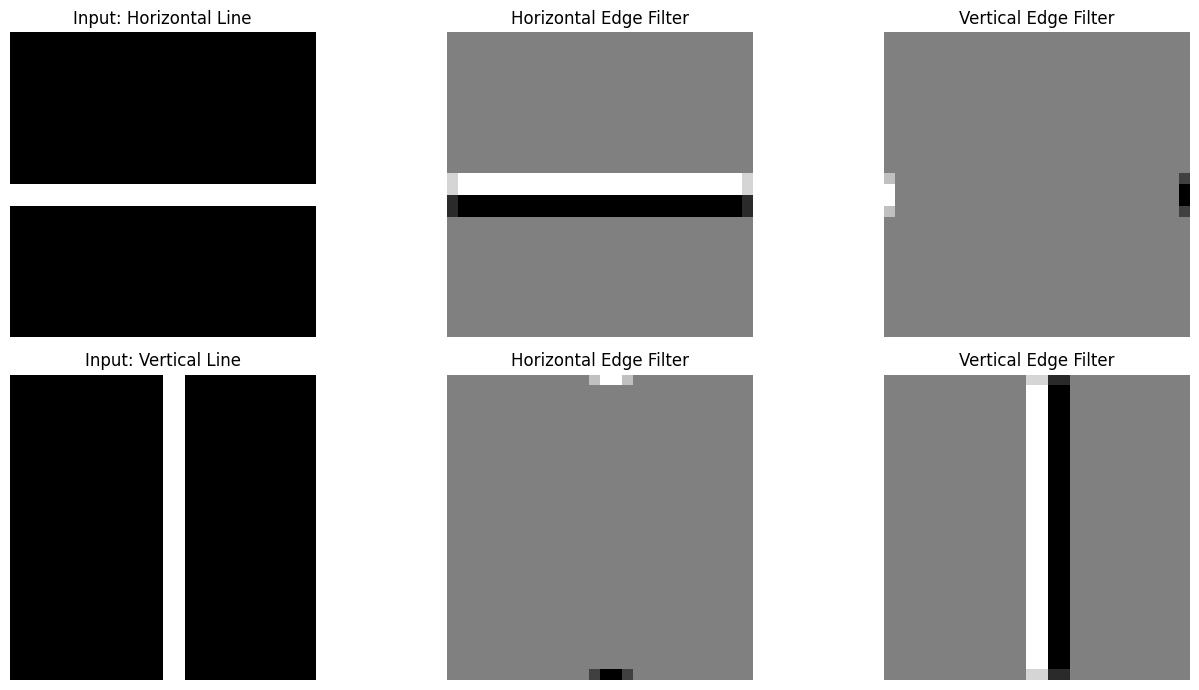

In [ ]:
# -----------------------------
# 1) 수평/수직 패턴 이미지 생성
# -----------------------------
H, W = 28, 28

# 수평 패턴: 가운데 가로줄(두께 2)
img_h = np.zeros((H, W), dtype=np.float32)
r = H // 2
img_h[r, :] = 1.0
img_h[min(r+1, H-1), :] = 1.0

# 수직 패턴: 가운데 세로줄(두께 2)
img_v = np.zeros((H, W), dtype=np.float32)
c = W // 2
img_v[:, c] = 1.0
img_v[:, min(c+1, W-1)] = 1.0

# Tensor로 변환 (N, C, H, W)
img_h_tensor = torch.from_numpy(img_h).unsqueeze(0).unsqueeze(0)  # (1,1,28,28)
img_v_tensor = torch.from_numpy(img_v).unsqueeze(0).unsqueeze(0)

# -----------------------------
# 2) 필터 정의 (out=1, in=1, kH, kW)
# -----------------------------
# 수평 엣지 검출: 위/아래 밝기 변화에 반응 → "수평 경계선" 검출
horizontal_edge = torch.tensor([[[-1., -1., -1.],
                                  [ 0.,  0.,  0.],
                                  [ 1.,  1.,  1.]]], dtype=torch.float32).unsqueeze(0)

# 수직 엣지 검출: 좌/우 밝기 변화에 반응 → "수직 경계선" 검출
vertical_edge = torch.tensor([[[-1., 0., 1.],
                                [-1., 0., 1.],
                                [-1., 0., 1.]]], dtype=torch.float32).unsqueeze(0)

# -----------------------------
# 3) Convolution 적용
# -----------------------------
pad = 1
out_h_on_h = F.conv2d(img_h_tensor, horizontal_edge, padding=pad)
out_v_on_h = F.conv2d(img_h_tensor, vertical_edge, padding=pad)

out_h_on_v = F.conv2d(img_v_tensor, horizontal_edge, padding=pad)
out_v_on_v = F.conv2d(img_v_tensor, vertical_edge, padding=pad)

# -----------------------------
# 4) 시각화 (수평/수직 이미지 각각 결과 비교)
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Row 0: 수평 패턴 입력
axes[0, 0].imshow(img_h, cmap='gray')
axes[0, 0].set_title('Input: Horizontal Line')
axes[0, 0].axis('off')

axes[0, 1].imshow(out_h_on_h.squeeze().detach().numpy(), cmap='gray')
axes[0, 1].set_title('Horizontal Edge Filter')
axes[0, 1].axis('off')

axes[0, 2].imshow(out_v_on_h.squeeze().detach().numpy(), cmap='gray')
axes[0, 2].set_title('Vertical Edge Filter')
axes[0, 2].axis('off')

# Row 1: 수직 패턴 입력
axes[1, 0].imshow(img_v, cmap='gray')
axes[1, 0].set_title('Input: Vertical Line')
axes[1, 0].axis('off')

axes[1, 1].imshow(out_h_on_v.squeeze().detach().numpy(), cmap='gray')
axes[1, 1].set_title('Horizontal Edge Filter')
axes[1, 1].axis('off')

axes[1, 2].imshow(out_v_on_v.squeeze().detach().numpy(), cmap='gray')
axes[1, 2].set_title('Vertical Edge Filter')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

---

## 3. 종합 실습: 간단한 Feature Extractor 만들기

지금까지 배운 내용을 종합해서 간단한 특징 추출기를 만들어봅시다.

**구조:**
1. Conv2d (1 → 8 channels, 3x3 kernel, padding=1)
2. ReLU
3. MaxPool2d (2x2)
4. Conv2d (8 → 16 channels, 3x3 kernel, padding=1)
5. ReLU
6. MaxPool2d (2x2)

In [ ]:
class SimpleFeatureExtractor(nn.Module):
    def __init__(self):
        super(SimpleFeatureExtractor, self).__init__()

        # 첫 번째 Conv Block
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # 두 번째 Conv Block
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        # Conv1 → ReLU → Pool
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)

        # Conv2 → ReLU → Pool
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)

        return x

# 모델 생성 및 테스트
model = SimpleFeatureExtractor()
test_input = torch.randn(1, 1, 28, 28)  # MNIST 크기

output = model(test_input)
print(f"입력: {test_input.shape}")
print(f"출력: {output.shape}")
print(f"\n총 파라미터 수: {sum(p.numel() for p in model.parameters())}")

입력: torch.Size([1, 1, 28, 28])
출력: torch.Size([1, 16, 7, 7])

총 파라미터 수: 1248


---

## 🎯 오늘 배운 내용

1. **Convolution 연산**: 지역적 특징 추출
2. **Padding**: 출력 크기 조절 및 정보 보존
3. **Stride**: 다운샘플링 조절
4. **Pooling**: 크기 축소 및 강건성 향상
5. **nn.Conv2d**: PyTorch의 Convolution Layer
6. **Feature Extraction**: 여러 Conv Layer를 쌓아서 특징 추출

### 다음 시간에는...
실제 MNIST 데이터셋을 사용해서 완전한 CNN 모델을 만들고 학습해봅시다!